In [1]:
import torch
from torchvision.io import read_video
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import face_alignment

In [11]:
vid = read_video("./presentateur.mp4", output_format="TCHW")[0][:5]
hhh, www = vid.shape[2], vid.shape[3]
vid.to(dtype=torch.float32)
vid = torch.nn.functional.interpolate(vid, (hhh//2, www//2), mode="bilinear")
vid.to(dtype=torch.uint8)
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, face_detector='sfd')

In [12]:
# Face alignment accepts THWC
landmarks, _, bboxs = fa.get_landmarks_from_batch(vid, return_bboxes=True)
points = landmarks[0]
bbox = bboxs[0]

Face detector time: 4.429433345794678
Face alignement: 0.20323514938354492 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 1.2132279872894287 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.01739025115966797 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.010233163833618164 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.013679265975952148 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.018018007278442383 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.009769201278686523 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.015359163284301758 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.012653589248657227 Dimensions torch.Size([1, 3, 256, 256])
Face alignement: 0.004718780517578125 Dimensions torch.Size([1, 3, 256, 256])


In [13]:
from face_alignment.detection.retina.pytorch_retinaface import Pytorch_RetinaFace
rf = Pytorch_RetinaFace(top_k=50, keep_top_k=10, device="cpu")

Using device: cpu
Loading pretrained model from ./face_alignment/detection/retina/weights/mobilenet0.25_Final.pth
remove prefix 'module.'
Missing keys:0
Unused checkpoint keys:0
Used keys:300


In [14]:
img = vid[0].permute(1, 2 ,0)
retina_input = img.to(dtype=torch.float32)
dets = rf.detect_faces(retina_input)
cropped_faces, infos = rf.center_and_crop_rescale(retina_input, dets, scale_factor=1, shift_factor=0.5, aspect_ratio=1)
infos

[((62, 62), (283, 50, 345, 112)), ((50, 50), (659, 64, 709, 114))]

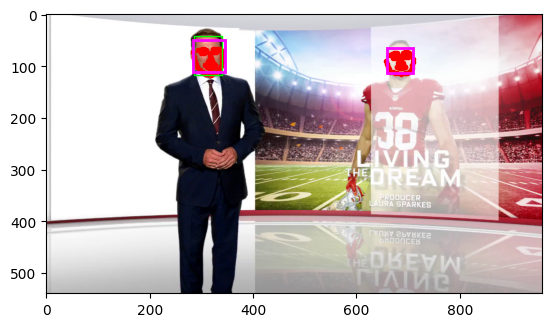

In [17]:
# SFD
plt.imshow(img)#, origin="lower")
plt.scatter(points[:, 0], points[:, 1], c='red', marker='.')

p1 = bbox[0][:2]
bw, bh = bbox[0][2] - bbox[0][0], bbox[0][3] - bbox[0][1]

rect = patches.Rectangle(p1, bw, bh, linewidth=1, edgecolor='lime', facecolor='none')
plt.gca().add_patch(rect)

# Retina
for i in range(len(infos)):
    rx1, ry1, rx2, ry2 = infos[i][1]
    rw, rh = infos[i][0]
    rectina = patches.Rectangle((rx1, ry1), rw, rh, linewidth=2, edgecolor='magenta', facecolor='none')
    plt.gca().add_patch(rectina)

# for i in range(len(dets)):
#     rbox = dets[i, 0:4]
#     rp1 = (rbox[0], rbox[1])
#     rw, rh = rbox[2] - rbox[0], rbox[3] - rbox[1]
#     rectina = patches.Rectangle(rp1, rw, rh, linewidth=1, edgecolor='magenta', facecolor='none')
#     plt.gca().add_patch(rectina)
    
# plt.scatter(points[:, 0], points[:, 1], c='red', marker='.')

In [16]:
dets

array([[2.8767169e+02, 4.4687435e+01, 3.4154071e+02, 1.1822355e+02,
        9.9921966e-01, 3.0392798e+02, 7.3882233e+01, 3.2926904e+02,
        7.1871353e+01, 3.1953525e+02, 8.7338753e+01, 3.0824738e+02,
        9.9267197e+01, 3.2901053e+02, 9.7641548e+01],
       [6.6207581e+02, 6.0496304e+01, 7.0737207e+02, 1.1893882e+02,
        9.9480492e-01, 6.7442310e+02, 8.2274902e+01, 6.9504962e+02,
        8.2192711e+01, 6.8515118e+02, 9.1804863e+01, 6.7596033e+02,
        1.0194212e+02, 6.9336786e+02, 1.0188098e+02],
       [7.3520959e+02, 4.2712775e+02, 7.4482849e+02, 4.3830569e+02,
        5.3846996e-02, 7.3743396e+02, 4.3164081e+02, 7.4177258e+02,
        4.3172882e+02, 7.3912061e+02, 4.3399194e+02, 7.3785205e+02,
        4.3613394e+02, 7.4122357e+02, 4.3602737e+02],
       [5.8360693e+02, 3.3974414e+02, 5.9321210e+02, 3.5183066e+02,
        3.0886421e-02, 5.8727332e+02, 3.4430627e+02, 5.9111707e+02,
        3.4448105e+02, 5.8913379e+02, 3.4712402e+02, 5.8740302e+02,
        3.4950958e+02,